# 🚀 Research-Grade SOTA Pruning Framework (V5 - Final Verified)

### ✨ Features:
1.  **Global vs. Local Pruning**: Choose between per-layer or global ranking.
2.  **SOTA Method Library**: Mean, APoZ, Variance, CHIP, and Taylor Expansion.
3.  **Visual Analytics**: Filter Kept/Pruned Heatmaps.
4.  **Fine-Tuning Recovery**: Automated recovery after weight surgery.

Using device: cuda


Baseline E1 Acc: 64.10%


Baseline E2 Acc: 73.22%


Baseline E3 Acc: 76.16%


Baseline E4 Acc: 81.03%


...

Fine-Tune E1 Acc: 91.13%


Fine-Tune E2 Acc: 91.96%


Fine-Tune E3 Acc: 94.74%


Fine-Tune E4 Acc: 94.93%


Fine-Tune E5 Acc: 94.95%


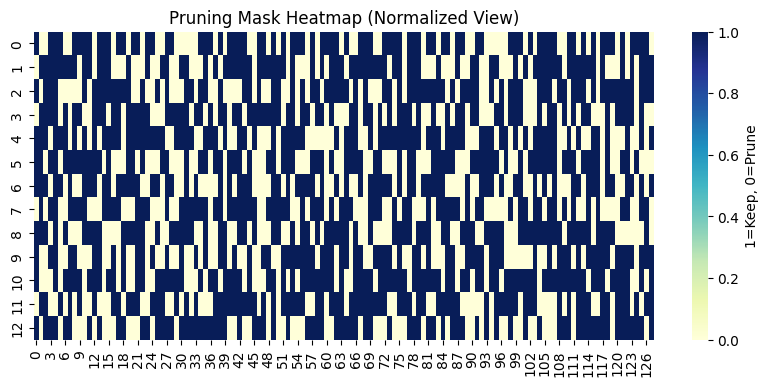

Final Accuracy: 94.93%


In [7]:
!pip -q install thop seaborn tqdm matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
import copy, os, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from abc import ABC, abstractmethod
from typing import Dict, List, Tuple
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from tqdm import tqdm
from thop import profile, clever_format

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =========================================
# 1. SOTA SCORING METHODS
# =========================================
class BaseCriterion(ABC):
    @abstractmethod
    def compute_scores(self, activations: torch.Tensor, gradients: torch.Tensor = None) -> torch.Tensor: pass

class MeanAbsCriterion(BaseCriterion):
    def compute_scores(self, activations, gradients=None): return activations.abs().mean(dim=(0, 2, 3))

class APoZCriterion(BaseCriterion):
    def compute_scores(self, activations, gradients=None): return (activations == 0).float().mean(dim=(0, 2, 3))

class VarianceCriterion(BaseCriterion):
    def compute_scores(self, activations, gradients=None): return activations.var(dim=(0, 2, 3))

class CHIPCriterion(BaseCriterion):
    def compute_scores(self, activations, gradients=None):
        b, c, h, w = activations.shape
        scores = []
        for i in range(c):
            f = activations[:, i].reshape(b, -1)
            _, s, _ = torch.svd(f)
            scores.append(s.sum())
        return torch.stack(scores).to(activations.device)

class TaylorCriterion(BaseCriterion):
    def compute_scores(self, activations, gradients=None):
        # First-order Taylor importance: |activation * gradient|
        if gradients is None: return activations.abs().mean(dim=(0, 2, 3))
        return (activations * gradients).abs().mean(dim=(0, 2, 3))

# =========================================
# 2. HEAVY LIFTING (Generalized Engine)
# =========================================
class PruningEngine:
    def __init__(self, model):
        self.model = model
        self.dependencies = self._trace()

    def _trace(self):
        mapping = {}
        mods = list(self.model.named_modules())
        for i, (name, m) in enumerate(mods):
            if isinstance(m, nn.Conv2d):
                sibs = [mods[i+1][0]] if (i+1 < len(mods) and isinstance(mods[i+1][1], nn.BatchNorm2d)) else []
                nxt = []
                for j in range(i+1, len(mods)):
                    if isinstance(mods[j][1], (nn.Conv2d, nn.Linear)): nxt.append(mods[j][0]); break
                mapping[name] = {"siblings": sibs, "next": nxt, "out_channels": m.out_channels}
        return mapping

    def apply_masks(self, model, masks: Dict[str, torch.Tensor]):
        new_model = copy.deepcopy(model)
        for l, m in masks.items():
            idx = torch.where(m)[0]
            orig_out = self.dependencies[l]["out_channels"]
            self._shrink(new_model, l, idx, 0)
            for s in self.dependencies[l]["siblings"]: self._shrink(new_model, s, idx, 0)
            for n in self.dependencies[l]["next"]: self._shrink(new_model, n, idx, 1, orig_out)
        return new_model

    def _shrink(self, model, name, idx, dim, source_channels=None):
        parts = name.split('.'); curr = model
        for p in parts[:-1]: curr = getattr(curr, p)
        m = getattr(curr, parts[-1])
        if isinstance(m, nn.Conv2d):
            if dim == 0:
                m.weight = nn.Parameter(m.weight.data[idx]); m.out_channels = len(idx)
                if m.bias is not None: m.bias = nn.Parameter(m.bias.data[idx])
            else:
                m.weight = nn.Parameter(m.weight.data[:, idx]); m.in_channels = len(idx)
        elif isinstance(m, nn.BatchNorm2d):
            m.weight = nn.Parameter(m.weight.data[idx]); m.bias = nn.Parameter(m.bias.data[idx])
            m.running_mean, m.running_var, m.num_features = m.running_mean[idx], m.running_var[idx], len(idx)
        elif isinstance(m, nn.Linear):
            if dim == 1:
                scale = m.in_features // source_channels
                new_idx = torch.cat([idx * scale + s for s in range(scale)]).sort()[0]
                m.weight = nn.Parameter(m.weight.data[:, new_idx]); m.in_features = len(new_idx)

# =========================================
# 3. ORCHESTRATOR
# =========================================
class PruningOrchestrator:
    def __init__(self, config):
        self.config = config
        
    def get_cifar_vgg(self):
        m = models.vgg16_bn(num_classes=10)
        m.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        m.classifier = nn.Sequential(nn.Linear(512, 512), nn.ReLU(True), nn.Dropout(), nn.Linear(512, 10))
        return m.to(device)

    def train(self, model, loader, epochs, name="Training"):
        opt = optim.Adam(model.parameters(), lr=self.config['lr'])
        crit = nn.CrossEntropyLoss()
        for e in range(epochs):
            model.train(); total_loss = 0
            for x, y in tqdm(loader, desc=f"{name} E{e+1}", leave=False):
                x, y = x.to(device), y.to(device)
                opt.zero_grad(); loss = crit(model(x), y); loss.backward(); opt.step()
                total_loss += loss.item()
            print(f"{name} E{e+1} Acc: {self.evaluate(model, loader):.2f}%")

    def evaluate(self, model, loader):
        model.eval(); correct, total = 0, 0
        with torch.no_grad():
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                correct += (model(x).argmax(1) == y).sum().item(); total += y.size(0)
        return 100 * correct / total

    def collect_scores(self, model, loader):
        scores = {}; acts = {}; grads = {}; model.eval(); crit = nn.CrossEntropyLoss()
        def f_hook(n): return lambda m, i, o: acts.update({n: o})
        def b_hook(n): return lambda m, i, o: grads.update({n: o[0]})
        hooks = []
        for n, m in model.named_modules():
            if isinstance(m, nn.Conv2d):
                hooks.append(m.register_forward_hook(f_hook(n)))
                hooks.append(m.register_full_backward_hook(b_hook(n)))
        try:
            x, y = next(iter(loader))
        except StopIteration:
            return {}
        x, y = x.to(device), y.to(device)
        out = model(x); loss = crit(out, y); model.zero_grad(); loss.backward()
        for h in hooks: h.remove()
        for n in acts.keys(): scores[n] = self.config['method'].compute_scores(acts[n], grads.get(n))
        return scores

    def run(self, model, loader):
        print("\n--- Starting Pruning Pipeline ---")
        self.engine = PruningEngine(model); scores = self.collect_scores(model, loader); masks = {}
        is_apoz = isinstance(self.config['method'], APoZCriterion)
        if self.config['scope'] == 'local':
            for l, s in scores.items():
                k = int(self.config['ratio'] * s.numel())
                _, p_idx = torch.topk(s, k, largest=is_apoz)
                m = torch.ones(s.numel(), dtype=torch.bool).to(device)
                m[p_idx] = False; masks[l] = m
        else:
            all_s = torch.cat(list(scores.values()))
            k = int(self.config['ratio'] * all_s.numel())
            thresh = torch.topk(all_s, k, largest=is_apoz)[0][-1]
            for l, s in scores.items(): masks[l] = (s > thresh) if not is_apoz else (s < thresh)
        pruned = self.engine.apply_masks(model, masks)
        print(f"Post-Surgery Acc: {self.evaluate(pruned, loader):.2f}%")
        print("🚀 Recovering Accuracy via Fine-Tuning...")
        self.train(pruned, loader, self.config['ft_epochs'], "Fine-Tune")
        return pruned, masks

# =========================================
# 4. VISUALIZATION
# =========================================
def visualize_results(masks):
    if not masks: return
    plt.figure(figsize=(10, 4))
    data = [np.resize(m.cpu().numpy(), (128,)) for m in masks.values()]
    sns.heatmap(data, cmap="YlGnBu", cbar_kws={'label': '1=Keep, 0=Prune'})
    plt.title("Pruning Mask Heatmap (Normalized View)")
    plt.show()

# =========================================
# 5. MAIN EXECUTION
# =========================================
methods = {"Mean": MeanAbsCriterion(), "APoZ": APoZCriterion(), "CHIP": CHIPCriterion(), "Taylor": TaylorCriterion(), "Var": VarianceCriterion()}
config = {'name': 'vgg_sota', 'lr': 3e-4, 'epochs': 15, 'ft_epochs': 5, 'ratio': 0.4, 'scope': 'local', 'method': methods["Taylor"]}
tf = transforms.Compose([transforms.RandomHorizontalFlip(), transforms.ToTensor(), transforms.Normalize((0.49, 0.48, 0.44), (0.20, 0.19, 0.20))])
try:
    loader = DataLoader(datasets.CIFAR10('./data', train=True, download=True, transform=tf), batch_size=128, shuffle=True)
    orch = PruningOrchestrator(config); model = orch.get_cifar_vgg()
    orch.train(model, loader, config['epochs'], "Baseline")
    pruned, masks = orch.run(model, loader)
    visualize_results(masks)
    print(f"Final Accuracy: {orch.evaluate(pruned, loader):.2f}%")
except Exception as e:
    print(f"Error in main execution: {e}")
